In [1]:
%cd ..

/scratch/big/home/daawic/BSc-Thesis


In [3]:
import os
import torch
import matplotlib.pyplot as plt
import torchvision.transforms as transforms 
from project.models import EDMSerie, EDMMauMau
from project.util.data import ReplayMemoryData

In [4]:
CHECKPOINT = os.path.join("..", "checkpoints", "diff", "Breakout.pt")
DATA = os.path.join("..", "checkpoints", "memory", "Breakout.pt")

In [5]:
device = "cuda:1"

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize(0.5, 0.5),
])

In [7]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500000,
    train=False
)

In [9]:
model_full = EDMSerie.from_checkpoint(CHECKPOINT, device=device, N=8, sigma_noise=1).to(device)
model_naive = EDMSerie.from_checkpoint(CHECKPOINT, device=device, sigma_noise=1).to(device)

In [10]:
sigmas = torch.arange(0.1, 1, 0.1)

In [17]:
y = data[2112].unsqueeze(0)
y_hat_naive = torch.zeros(sigmas.shape + y.shape[1:])
y_hat_full = torch.zeros(sigmas.shape + y.shape[1:])
w = torch.randn_like(y)

for i, sigma in enumerate(sigmas):

    model_naive.set_sigma_noise(sigma)
    model_full.set_sigma_noise(sigma)
    y_noisy = y + sigma * w

    y_hat_naive[i] = model_naive.denoise(y_noisy.to(device)).squeeze().cpu()
    y_hat_full[i] = model_full.denoise(y_noisy.to(device)).squeeze().cpu()

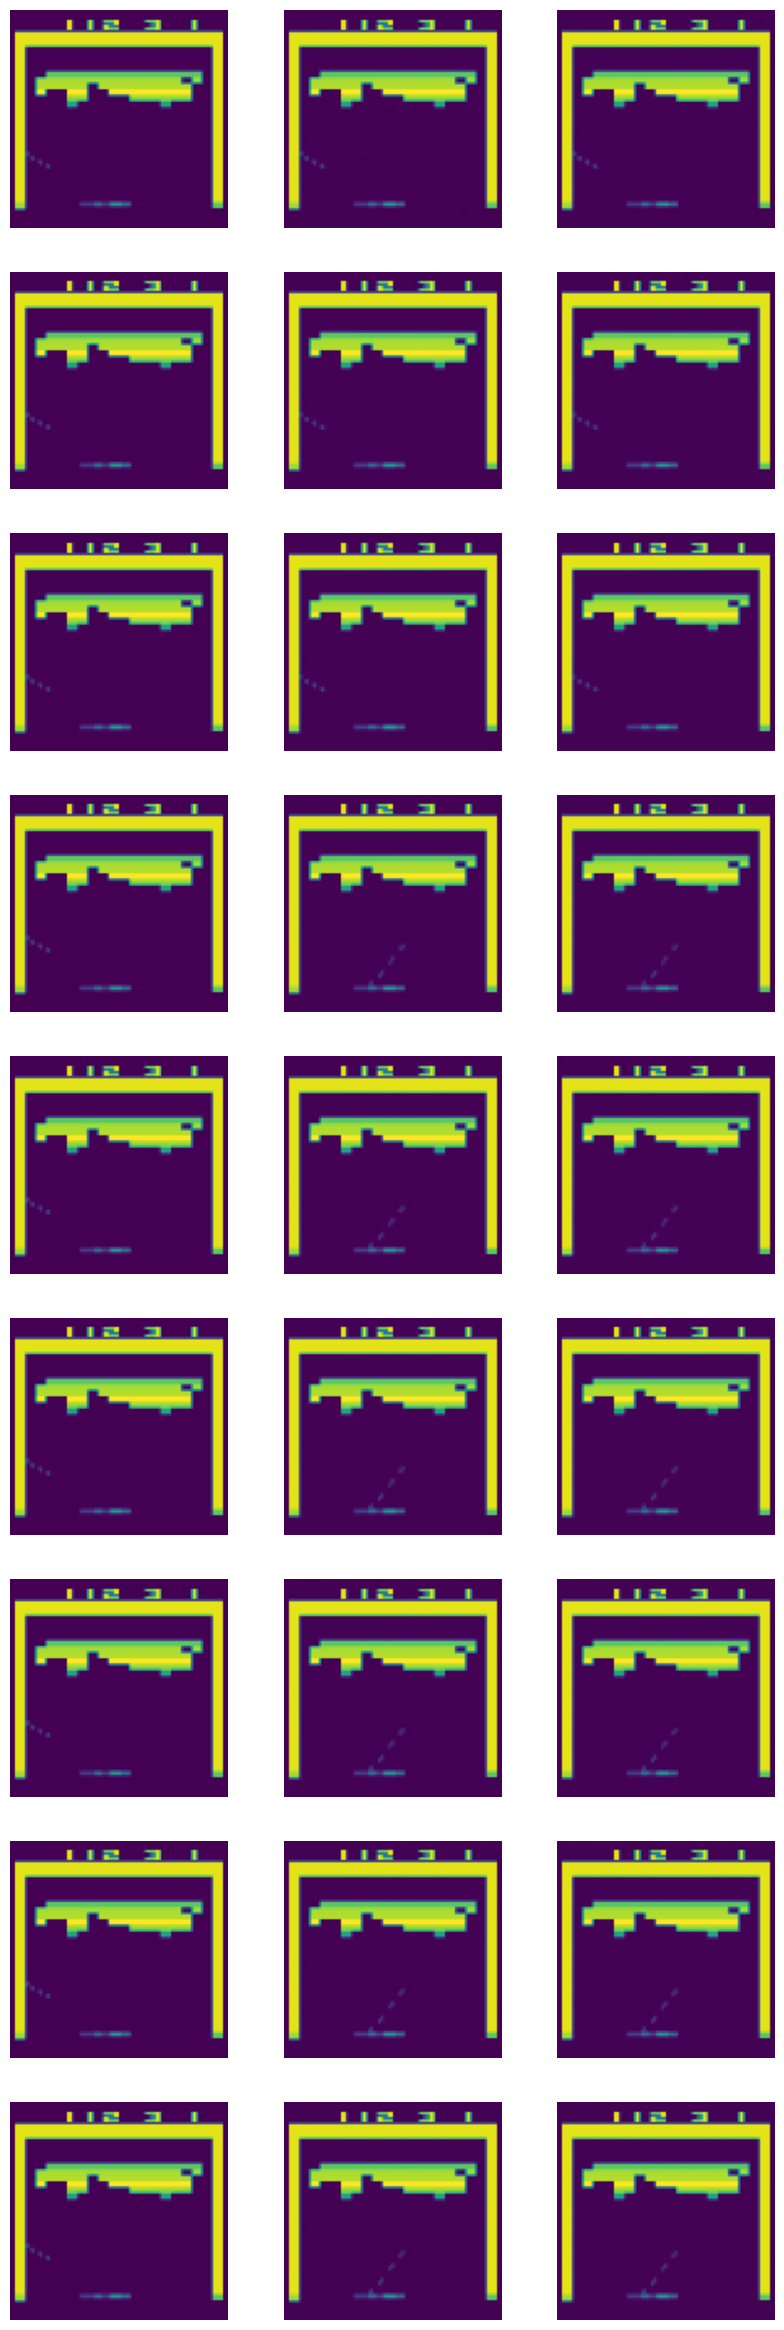

In [ ]:
fig, axis = plt.subplots(9, 3, figsize=(10, 30))

for i, sigma in enumerate(sigmas):
    axis[i, 0].imshow(y.squeeze().mean(0))
    axis[i, 1].imshow()
    axis[i, 1].imshow(y_hat_naive[i].mean(0))
    axis[i, 2].imshow(y_hat_full[i].mean(0))
    axis[i, 0].axis("off")
    axis[i, 1].axis("off")
    axis[i, 2].axis("off")